In [1]:
import random
import time
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset

from torchvision import transforms, models
from medmnist import PathMNIST

print("PyTorch:", torch.__version__)
print("CUDA disponível:", torch.cuda.is_available())

PyTorch: 2.12.0+cpu
CUDA disponível: False


In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Dispositivo usado:", device)

Dispositivo usado: cpu


In [3]:
transform_train = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

transform_val = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [4]:
train_set_224 = PathMNIST(
    split="train",
    size=224,
    transform=transform_train,
    download=True
)

val_set_224 = PathMNIST(
    split="val",
    size=224,
    transform=transform_val,
    download=True
)

print("Treino:", len(train_set_224))
print("Validação:", len(val_set_224))

Treino: 89996
Validação: 10004


In [5]:
train_subset = Subset(train_set_224, range(3000))
val_subset = Subset(val_set_224, range(800))

batch_size = 16

train_loader = DataLoader(
    train_subset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_subset,
    batch_size=batch_size,
    shuffle=False
)

print("Batches de treino:", len(train_loader))
print("Batches de validação:", len(val_loader))

Batches de treino: 188
Batches de validação: 50


In [6]:
imagens, labels = next(iter(train_loader))

print("Formato das imagens:", imagens.shape)
print("Formato dos labels:", labels.shape)
print("Primeiros labels:", labels[:10].squeeze())

Formato das imagens: torch.Size([16, 3, 224, 224])
Formato dos labels: torch.Size([16, 1])
Primeiros labels: tensor([4, 7, 2, 8, 8, 5, 6, 6, 6, 5])


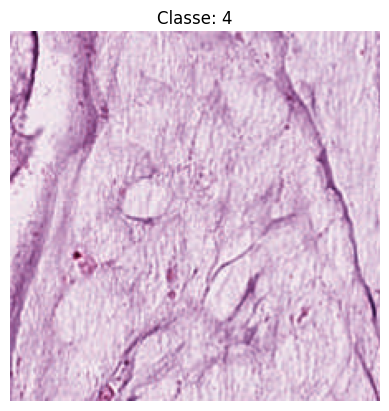

In [7]:
def mostrar_imagem_tensor(img_tensor, label):
    img = img_tensor.clone().permute(1, 2, 0).numpy()

    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    img = std * img + mean
    img = np.clip(img, 0, 1)

    plt.imshow(img)
    plt.title(f"Classe: {label}")
    plt.axis("off")
    plt.show()


mostrar_imagem_tensor(imagens[0], labels[0].item())

In [8]:
class CNNPropria(nn.Module):
    def __init__(self, num_classes=9):
        super().__init__()

        self.features = nn.Sequential(
            # Bloco 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Bloco 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Bloco 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Dropout(0.3)
        )

        self.classificador = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classificador(x)
        return x

In [9]:
cnn_propria = CNNPropria(num_classes=9).to(device)

imagens_teste, labels_teste = next(iter(train_loader))
imagens_teste = imagens_teste.to(device)

saidas = cnn_propria(imagens_teste)

print(cnn_propria)
print("Formato da saída:", saidas.shape)

CNNPropria(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Dropout(p=0.3, inplace=False)
  )
  (classificador): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(i

In [10]:
def treinar_uma_epoca(modelo, dataloader, criterio, otimizador, device):
    modelo.train()

    perda_total = 0
    acertos = 0
    total = 0

    for imagens, labels in dataloader:
        imagens = imagens.to(device)
        labels = labels.squeeze().long().to(device)

        otimizador.zero_grad()

        saidas = modelo(imagens)
        perda = criterio(saidas, labels)

        perda.backward()
        otimizador.step()

        perda_total += perda.item() * imagens.size(0)

        previsoes = torch.argmax(saidas, dim=1)
        acertos += (previsoes == labels).sum().item()
        total += labels.size(0)

    perda_media = perda_total / total
    acuracia = acertos / total

    return perda_media, acuracia


def avaliar(modelo, dataloader, criterio, device):
    modelo.eval()

    perda_total = 0
    acertos = 0
    total = 0

    with torch.no_grad():
        for imagens, labels in dataloader:
            imagens = imagens.to(device)
            labels = labels.squeeze().long().to(device)

            saidas = modelo(imagens)
            perda = criterio(saidas, labels)

            perda_total += perda.item() * imagens.size(0)

            previsoes = torch.argmax(saidas, dim=1)
            acertos += (previsoes == labels).sum().item()
            total += labels.size(0)

    perda_media = perda_total / total
    acuracia = acertos / total

    return perda_media, acuracia

In [11]:
cnn_propria = CNNPropria(num_classes=9).to(device)

criterio = nn.CrossEntropyLoss()

otimizador = optim.Adam(
    cnn_propria.parameters(),
    lr=0.001
)

print("CNN própria criada e pronta para treinamento.")

CNN própria criada e pronta para treinamento.


In [12]:
historico_cnn = {
    "loss_train": [],
    "acc_train": [],
    "loss_val": [],
    "acc_val": []
}

epocas = 5

inicio = time.time()

for epoca in range(1, epocas + 1):
    loss_train, acc_train = treinar_uma_epoca(
        cnn_propria,
        train_loader,
        criterio,
        otimizador,
        device
    )

    loss_val, acc_val = avaliar(
        cnn_propria,
        val_loader,
        criterio,
        device
    )

    historico_cnn["loss_train"].append(loss_train)
    historico_cnn["acc_train"].append(acc_train)
    historico_cnn["loss_val"].append(loss_val)
    historico_cnn["acc_val"].append(acc_val)

    print(
        f"Época {epoca:02d} | "
        f"Loss treino: {loss_train:.4f} | Acc treino: {acc_train:.4f} | "
        f"Loss val: {loss_val:.4f} | Acc val: {acc_val:.4f}"
    )

fim = time.time()

tempo_total = fim - inicio
print(f"Tempo total de treinamento: {tempo_total:.2f} segundos")

Época 01 | Loss treino: 4.7332 | Acc treino: 0.2360 | Loss val: 1.8393 | Acc val: 0.2938
Época 02 | Loss treino: 1.8886 | Acc treino: 0.2607 | Loss val: 1.6772 | Acc val: 0.3287
Época 03 | Loss treino: 1.8986 | Acc treino: 0.2573 | Loss val: 1.6778 | Acc val: 0.3075
Época 04 | Loss treino: 1.8261 | Acc treino: 0.2683 | Loss val: 1.5972 | Acc val: 0.3212
Época 05 | Loss treino: 1.8393 | Acc treino: 0.2697 | Loss val: 1.6807 | Acc val: 0.3187
Tempo total de treinamento: 1475.58 segundos


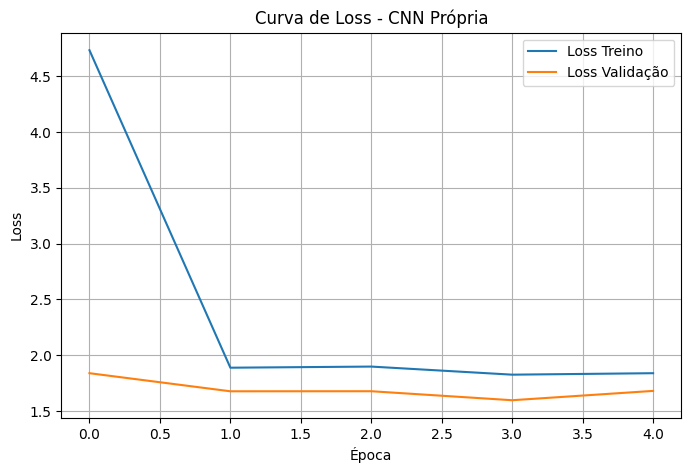

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(historico_cnn["loss_train"], label="Loss Treino")
plt.plot(historico_cnn["loss_val"], label="Loss Validação")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Curva de Loss - CNN Própria")
plt.legend()
plt.grid(True)
plt.show()

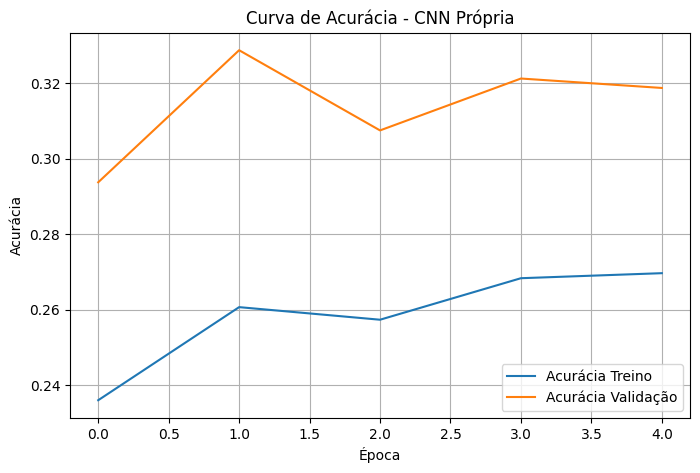

In [14]:
plt.figure(figsize=(8, 5))
plt.plot(historico_cnn["acc_train"], label="Acurácia Treino")
plt.plot(historico_cnn["acc_val"], label="Acurácia Validação")
plt.xlabel("Época")
plt.ylabel("Acurácia")
plt.title("Curva de Acurácia - CNN Própria")
plt.legend()
plt.grid(True)
plt.show()

## CNN própria

Foi implementada uma CNN autoral com três blocos convolucionais, utilizando convolução 2D, Batch Normalization, ReLU, MaxPooling e Dropout. A entrada utilizada foi o PathMNIST na resolução 224x224, conforme especificado no enunciado.

Devido às limitações computacionais do ambiente local, o treinamento foi realizado inicialmente com um subconjunto de 3000 imagens de treino e 800 imagens de validação, usando batch size 16 e 5 épocas. O objetivo desta etapa foi validar a arquitetura e demonstrar o funcionamento de uma CNN própria antes de avançar para modelos pré-treinados.